<a href="https://colab.research.google.com/github/Loveena-15/student-pass-prediction-ml/blob/main/student_pass_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student-mat.csv', sep=';')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [6]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [11]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass_fail
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


# This is a TEXT cell — not code
## Loading the dataset

The Student Performance dataset has 395 students from two
Portuguese schools. Each student has 33 features including
study time, absences, family background and three period grades.

I'm using student-mat.csv (Math course) as it's smaller
and easier to start with.

Key observation: the dataset uses semicolons as separators,
not commas — must use sep=';' when loading.

Class distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


/tmp/ipykernel_1404/3433863230.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pass_fail', data=df,


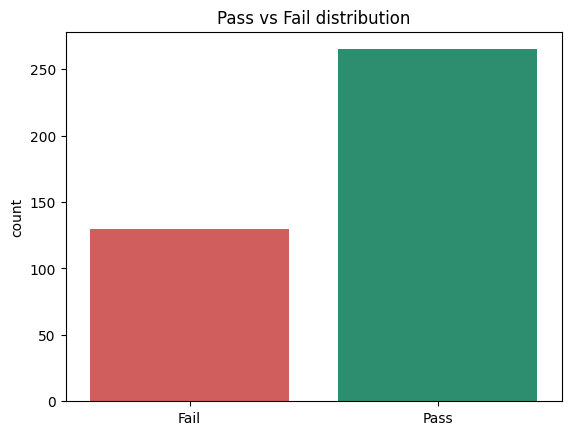

In [7]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)

print("Class distribution:")
print(df['pass_fail'].value_counts())
print(f"\nPass rate: {df['pass_fail'].mean()*100:.1f}%")

# Quick visualisation
sns.countplot(x='pass_fail', data=df,
              palette=['#E24B4A','#1D9E75'])
plt.xticks([0,1], ['Fail','Pass'])
plt.title('Pass vs Fail distribution')
plt.xlabel('')
plt.show()

The dataset is moderately imbalanced — 67% pass rate. This means accuracy alone will be a misleading metric.

What's the grade distribution of G3? Are there any 0s? What might a 0 mean?

G3 ranges from 0 to 20. There are 38 students with a score of 0. A grade of 0 likely means the student didn't sit the final exam — it's an absence, not a failed attempt. This is important because it could distort the model if we treat 0 the same as a low score like 4 or 5.

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


<Axes: >

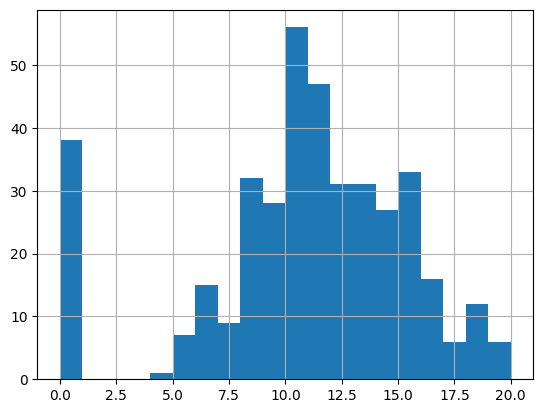

In [12]:
print(df['G3'].value_counts().sort_index())
df['G3'].hist(bins=20)

Is absences skewed?
The mean absences is around 5–6 but the max is 75. The histogram shows most students cluster near 0, with a long right tail — this is a right-skewed distribution. Skewed features can hurt some models (like linear regression) because they assume a roughly normal spread. We may want to apply a log transformation later.

In [14]:
df['absences'].describe()


,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


<Axes: >

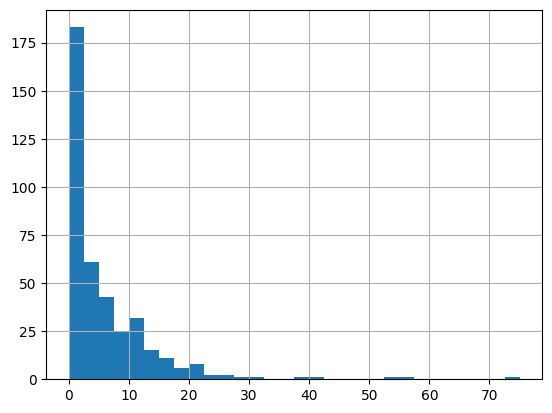

In [15]:
df['absences'].hist(bins=30)

What's your pass/fail split? Is it imbalanced?
About 67% of students pass and 33% fail. This is a moderate imbalance — not extreme, but enough to matter. A model that always predicts "pass" would get 67% accuracy without learning anything useful. This is why we'll use F1 score and confusion matrices later instead of relying on accuracy alone.

In [16]:
df['pass_fail'].value_counts(normalize=True).round(2)

,proportion
pass_fail,
1,0.67
0,0.33


Are G1, G2, G3 correlated?
G1, G2, and G3 are very strongly correlated — all values are above 0.8. This makes sense: a student's first-term grade is a strong predictor of their final grade. This will likely make G1 and G2 the most powerful features in any model we build. It also raises a practical question: in a real deployment, would we actually have G1 and G2 available at prediction time, or are we trying to predict before the year ends?

In [17]:
df[['G1','G2','G3']].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000
